# Solutions · 18 · Monte Carlo simulation

Worked solutions to the exercises of [notebook 18](../notebooks/18_monte_carlo.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import montecarlo
from scipy import stats

## Exercise 1

Estimate $\pi$ with Buffon's needle: drop needles of length $\ell$ on lines spaced $d \ge \ell$ apart;
   $P(\text{cross}) = 2\ell/(\pi d)$. How many throws for three correct digits?

In [2]:
rng = np.random.default_rng(18)
ell, d = 1.0, 2.0
N = 1_000_000
centre = rng.uniform(0, d/2, N)                     # distance of the needle centre to the nearest line
angle = rng.uniform(0, np.pi/2, N)
p_hat = np.mean(centre <= ell/2*np.sin(angle))
pi_hat = 2*ell/(d*p_hat)
se = pi_hat*np.sqrt((1 - p_hat)/(p_hat*N))          # relative error of pi = relative error of p
print(f"pi ≈ {pi_hat:.4f} ± {se:.4f} from {N:,} needles")
N3 = (1 - p_hat)/p_hat * (np.pi/0.0005)**2
print(f"needles for ±0.0005 (three decimals, one standard error): about {N3:,.0f}")

pi ≈ 3.1347 ± 0.0046 from 1,000,000 needles
needles for ±0.0005 (three decimals, one standard error): about 84,273,722


Buffon's needle is a beautiful experiment but a terrible way to compute $\pi$: the error shrinks like
$1/\sqrt N$, so each extra correct digit costs 100 times more throws - three decimal places need tens of
millions of needles. (The simulation also uses $\pi$ to draw the random angles; a physical experiment
would not.)

## Exercise 2

**Importance sampling.** Draw loads from $N(360, 30)$ instead of $N(300, 30)$ (more failures) and
   correct each sample with the weight $\phi_{300}(L)/\phi_{360}(L)$. How much smaller is the standard
   error for the same N?

In [3]:
N = 100_000
rng = np.random.default_rng(1)
pf_exact = stats.norm.cdf(-(400 - 300)/np.hypot(25, 30))
L_plain = rng.normal(300, 30, N); S = rng.normal(400, 25, N)
fails = L_plain > S
p_plain, se_plain = fails.mean(), np.sqrt(fails.mean()*(1 - fails.mean())/N)
L_is = rng.normal(360, 30, N); S = rng.normal(400, 25, N)
w = stats.norm.pdf(L_is, 300, 30) / stats.norm.pdf(L_is, 360, 30)   # likelihood-ratio weights
vals = (L_is > S) * w
p_is, se_is = vals.mean(), vals.std(ddof=1)/np.sqrt(N)
print(f"exact {pf_exact:.5f}")
print(f"plain Monte Carlo:   {p_plain:.5f} ± {se_plain:.5f}")
print(f"importance sampling, load shifted: {p_is:.5f} ± {se_is:.5f}  ({se_plain/se_is:.1f}x smaller standard error)")
# shift BOTH variables towards the most likely failure point ("design point", about 359 MPa for both)
L2, S2 = rng.normal(360, 30, N), rng.normal(359, 25, N)
w2 = stats.norm.pdf(L2, 300, 30)/stats.norm.pdf(L2, 360, 30) * stats.norm.pdf(S2, 400, 25)/stats.norm.pdf(S2, 359, 25)
vals2 = (L2 > S2) * w2
se2 = vals2.std(ddof=1)/np.sqrt(N)
print(f"importance sampling, both shifted: {vals2.mean():.5f} ± {se2:.5f}  ({se_plain/se2:.1f}x smaller standard error, "
      f"about {(se_plain/se2)**2:.0f}x fewer samples for the same accuracy)")

exact 0.00522
plain Monte Carlo:   0.00538 ± 0.00023
importance sampling, load shifted: 0.00544 ± 0.00016  (1.4x smaller standard error)
importance sampling, both shifted: 0.00516 ± 0.00003  (8.3x smaller standard error, about 69x fewer samples for the same accuracy)


Sampling the load from a distribution shifted towards failure produces many more failures to count; the
weights correct for sampling "the wrong" distribution, so the estimate stays unbiased. Shifting only the
load helps modestly (failures still need a low strength, which remains rare). Shifting **both** variables
towards the most likely failure point - where load and strength meet, near 359 MPa - cuts the standard
error about eightfold: some 70 times fewer samples for the same accuracy. Importance sampling is the standard tool for
the very small failure probabilities of structural reliability ($10^{-4}$ to $10^{-7}$), where plain Monte
Carlo would need billions of samples.

## Exercise 3

Simulate 3D walks and confirm $\langle r^2\rangle = n$. Use the result to relate the step length and time
   step of a walker to a diffusion coefficient $D$.

fitted <r²> per step: 0.991  (theory 1 for unit steps)


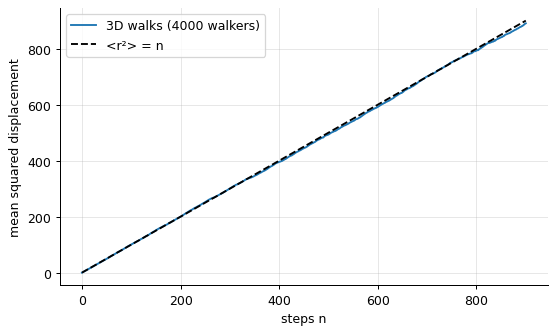

with 0.1 nm steps every 1 ps: D = step²/(2 d dt) = 1.67e-09 m²/s


In [4]:
walk = montecarlo.random_walk(900, 4000, dim=3, seed=7)
msd = np.mean(np.sum(walk**2, axis=2), axis=1)
steps = np.arange(msd.size)
slope = np.polyfit(steps, msd, 1)[0]
print(f"fitted <r²> per step: {slope:.3f}  (theory 1 for unit steps)")
plt.plot(steps, msd, label="3D walks (4000 walkers)"); plt.plot(steps, steps, "k--", label="<r²> = n")
plt.xlabel("steps n"); plt.ylabel("mean squared displacement"); plt.legend(); plt.show()
step_len, dt = 1e-10, 1e-12                          # molecular scale: 0.1 nm steps every picosecond
print(f"with {step_len*1e9:.1f} nm steps every {dt*1e12:.0f} ps: D = step²/(2 d dt) = {step_len**2/(2*3*dt):.2e} m²/s")

In three dimensions too, $\langle r^2\rangle = n\,\ell^2$ for steps of length $\ell$. After time $t = n\,\Delta t$, comparing with
the diffusion result $\langle r^2\rangle = 2dDt$ ($d$ = 3 dimensions) gives $D = \ell^2/(2d\,\Delta t)$. With molecular step
lengths and times this reproduces the order of magnitude of diffusion coefficients in liquids,
$10^{-9}$ to $10^{-10}$ m²/s: the macroscopic diffusion equation emerges from microscopic randomness.

## Exercise 4

**Implement it yourself:** write a Monte Carlo estimate of the probability that the sum of 12 uniform(0, 1) numbers exceeds 8, with its standard error. Compare with the normal approximation (mean 6, variance 1) and explain the difference.

In [5]:
rng = np.random.default_rng(12)
N = 2_000_000
sums = rng.random((N, 12), dtype=np.float32).sum(axis=1)
p = np.mean(sums > 8)
print(f"Monte Carlo: P(sum > 8) = {p:.5f} ± {np.sqrt(p*(1 - p)/N):.5f}")
print(f"normal approximation (mean 6, variance 1): {stats.norm.sf(8, 6, 1):.5f}")
from math import comb, factorial                     # exact (Irwin-Hall distribution)
cdf8 = sum((-1)**k * comb(12, k) * (8 - k)**12 for k in range(9)) / factorial(12)
print(f"exact (Irwin-Hall): {1 - cdf8:.5f}")
cdf10 = sum((-1)**k * comb(12, k) * (10 - k)**12 for k in range(11)) / factorial(12)
print(f"further out, P(sum > 10): exact {1 - cdf10:.2e}, normal approximation {stats.norm.sf(10, 6, 1):.2e} "
      f"({stats.norm.sf(10, 6, 1)/(1 - cdf10):.1f}x too large)")

Monte Carlo: P(sum > 8) = 0.02237 ± 0.00010
normal approximation (mean 6, variance 1): 0.02275
exact (Irwin-Hall): 0.02228
further out, P(sum > 10): exact 8.53e-06, normal approximation 3.17e-05 (3.7x too large)


The sum of 12 uniforms has mean 6 and variance 1, and its distribution is close to normal - an old way of
generating normal random numbers. But in the **tails** the difference shows: the sum can never exceed 12,
and its tails are lighter than the normal distribution's. At a sum of 8 (two standard deviations) the
normal approximation is only about 2 % too high, but further out the error grows quickly: at 10 it
overestimates the probability almost fourfold. The central limit theorem describes the middle of a
distribution far better than its tails - exactly where failure probabilities live.